# 1D Allen-Cahn with EvoKAN-SF

- Problem:
  1D Allen-Cahn equation on $x \in [-1,1]$
- Governing equation:
  $$
  \partial_t u = \partial_{xx} u - \frac{1}{\varepsilon^2} u(u^2-1)
  $$
- Initial condition:
  $$
  u(x,0)=0.08\sin(\pi x)
  $$
- Boundary condition:
  $$
  u(-1,t)=u(1,t)=0
  $$
- Formulation:
  strong-form evolutionary KAN
- Workflow:
  fit the initial profile first, then evolve trainable parameters in time


In [1]:
import torch
import numpy as np
import random
import scipy

# --- Set a consistent random seed ---
seed = 5
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

from typing import *

class SplineLinear(nn.Linear):
    def __init__(self, in_features: int, out_features: int, init_scale: float = 0.1, **kw) -> None:
        self.init_scale = init_scale
        super().__init__(in_features, out_features, bias=False, **kw)

    def reset_parameters(self) -> None:
        nn.init.trunc_normal_(self.weight, mean=0, std=self.init_scale)

class RadialBasisFunction(nn.Module):
    def __init__(
        self,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        denominator: float = None,  # larger denominators lead to smoother basis functions.
    ):
        super().__init__()
        self.grid_min = grid_min
        self.grid_max = grid_max
        self.num_grids = num_grids
        
        # Create the grid tensor and register it as a buffer
        grid_tensor = torch.linspace(grid_min, grid_max, num_grids)
        self.register_buffer('grid', grid_tensor)
        
        # If denominator is not given, compute the default value and register it as a buffer
        computed_denom = denominator if denominator is not None else (grid_max - grid_min) / (num_grids - 1)
        self.register_buffer('denominator', torch.tensor(computed_denom, dtype=grid_tensor.dtype))

    def forward(self, x):
        return torch.exp(-((x[..., None] - self.grid) / self.denominator) ** 2) * (x[..., None]**2)
        # return torch.exp(-((x[..., None] - self.grid) / self.denominator) ** 2) 


class FastKANLayer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        use_base_update: bool = True,
        use_layernorm: bool = False,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.layernorm = None
        if use_layernorm:
            assert input_dim > 1, "Do not use layernorms on 1D inputs. Set `use_layernorm=False`."
            self.layernorm = nn.LayerNorm(input_dim)
        self.rbf = RadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = SplineLinear(input_dim * num_grids, output_dim, spline_weight_init_scale)
        self.use_base_update = use_base_update
        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = nn.Linear(input_dim, output_dim, bias=False)

    def forward(self, x, use_layernorm=True):
        if self.layernorm is not None and use_layernorm:
            spline_basis = self.rbf(self.layernorm(x))
        else:
            spline_basis = self.rbf(x)
        ret = self.spline_linear(spline_basis.view(*spline_basis.shape[:-2], -1))
        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base
        return ret

    def plot_curve(
        self,
        input_index: int,
        output_index: int,
        num_pts: int = 1000,
        num_extrapolate_bins: int = 2
    ):
        '''this function returns the learned curves in a FastKANLayer.
        input_index: the selected index of the input, in [0, input_dim) .
        output_index: the selected index of the output, in [0, output_dim) .
        num_pts: num of points sampled for the curve.
        num_extrapolate_bins (N_e): num of bins extrapolating from the given grids. The curve
            will be calculate in the range of [grid_min - h * N_e, grid_max + h * N_e].
        '''
        ng = self.rbf.num_grids
        h = self.rbf.denominator
        assert input_index < self.input_dim
        assert output_index < self.output_dim
        w = self.spline_linear.weight[
            output_index, input_index * ng : (input_index + 1) * ng
        ]   # num_grids,
        x = torch.linspace(
            self.rbf.grid_min - num_extrapolate_bins * h,
            self.rbf.grid_max + num_extrapolate_bins * h,
            num_pts
        )   # num_pts, num_grids
        with torch.no_grad():
            y = (w * self.rbf(x.to(w.dtype))).sum(-1)
        return x, y

In [3]:
class FirstRadialBasisFunction(nn.Module):
    def __init__(
        self,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        denominator: float = None,  # larger denominators lead to smoother basis
    ):
        super().__init__()
        self.grid_min = grid_min
        self.grid_max = grid_max
        self.num_grids = num_grids
        self.grid = torch.linspace(grid_min, grid_max, num_grids)
        #self.grid = torch.nn.Parameter(grid, requires_grad=False)
        self.denominator = denominator or (grid_max - grid_min) / (num_grids - 1)
        
    def forward(self, x):
        # Move to the same device as x
        grid = self.grid.to(x.device)
        denominator = torch.tensor(self.denominator, dtype=x.dtype, device=x.device)
        return torch.exp(-((x[..., None] - grid) / denominator) ** 2) * (x[..., None]**2 - 1)
        # return torch.exp(-((x[..., None] - grid) / denominator) ** 2)
        
    # def forward(self, x):
    #     return torch.exp(-((x[..., None] - self.grid) / self.denominator) ** 2) * (x[..., None]**2 - 1)

class FastKANFirstLayer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        use_base_update: bool = False,
        use_layernorm: bool = False,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.layernorm = None
        if use_layernorm:
            assert input_dim > 1, "Do not use layernorms on 1D inputs. Set `use_layernorm=False`."
            self.layernorm = nn.LayerNorm(input_dim)
        self.rbf = FirstRadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = SplineLinear(input_dim * num_grids, output_dim, spline_weight_init_scale)
        self.use_base_update = use_base_update
        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = nn.Linear(input_dim, output_dim)

    def forward(self, x, use_layernorm=True):
        if self.layernorm is not None and use_layernorm:
            spline_basis = self.rbf(self.layernorm(x))
        else:
            spline_basis = self.rbf(x)
        ret = self.spline_linear(spline_basis.view(*spline_basis.shape[:-2], -1))
        if self.use_base_update:
            base = self.base_linear(self.base_activation(x)) * (x[..., None]**2)
            # base = self.base_linear(self.base_activation(x))
            ret = ret + base
        return ret

    def plot_curve(
        self,
        input_index: int,
        output_index: int,
        num_pts: int = 1000,
        num_extrapolate_bins: int = 2
    ):
        '''this function returns the learned curves in a FastKANLayer.
        input_index: the selected index of the input, in [0, input_dim) .
        output_index: the selected index of the output, in [0, output_dim) .
        num_pts: num of points sampled for the curve.
        num_extrapolate_bins (N_e): num of bins extrapolating from the given grids. The curve
            will be calculate in the range of [grid_min - h * N_e, grid_max + h * N_e].
        '''
        ng = self.rbf.num_grids
        h = self.rbf.denominator
        assert input_index < self.input_dim
        assert output_index < self.output_dim
        w = self.spline_linear.weight[
            output_index, input_index * ng : (input_index + 1) * ng
        ]   # num_grids,
        x = torch.linspace(
            self.rbf.grid_min - num_extrapolate_bins * h,
            self.rbf.grid_max + num_extrapolate_bins * h,
            num_pts
        )   # num_pts, num_grids
        with torch.no_grad():
            y = (w * self.rbf(x.to(w.dtype))).sum(-1)
        return x, y

In [4]:
class KAN(torch.nn.Module):
    def __init__(
        self,
        layers_hidden,
        grid_min: float = -1.,
        grid_max: float = 1.,
        num_grids: int = 4,
        use_base_update: bool = True,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ):
        super(KAN, self).__init__()
        self.layers = torch.nn.ModuleList()


        self.layers.append(
                FastKANFirstLayer(
                    input_dim = 1,
                    output_dim = 3,
                    grid_min=grid_min,
                    grid_max=grid_max,
                    num_grids=num_grids,
                    use_base_update=False,
                    base_activation=base_activation,
                    spline_weight_init_scale=spline_weight_init_scale,
                )
            )


        for in_features, out_features in zip(layers_hidden[1:], layers_hidden[2:]):
            self.layers.append(
                FastKANLayer(
                    in_features,
                    out_features,
                    grid_min=grid_min,
                    grid_max=grid_max,
                    num_grids=num_grids,
                    use_base_update=use_base_update,
                    base_activation=base_activation,
                    spline_weight_init_scale=spline_weight_init_scale,
                )
            )

    # def forward(self, x: torch.Tensor, update_grid=False):
    #     #y = torch.clone(torch.hstack((torch.sin(torch.tensor(math.pi)*x), (torch.cos(torch.tensor(math.pi)*x) + 1))))
    #     x_in = torch.clone(x)
    #     y = torch.clone(x)
    #     for layer in self.layers:
    #         y = layer(y)
    #     return (1 - x_in**2) * y
    
    def forward(self, x: torch.Tensor, update_grid=False):
        #y = torch.clone(torch.hstack((torch.sin(torch.tensor(math.pi)*x), (torch.cos(torch.tensor(math.pi)*x) + 1))))
        # x_in = torch.clone(x)
        y = torch.clone(x)
        for layer in self.layers:
            y = layer(y)
        return y

## Experiment Setup

- Random seed:
  `5`
- Spatial samples for the initial-condition fit:
  `num_of_x = 64`
- Network:
  `KAN([1, 3, 3, 3, 3, 1])`
- Hidden-layer pattern:
  four hidden layers with width `3`
- Basis / activation:
  Gaussian RBF + `SiLU`
- Grid points per layer:
  `4`
- Initial-fit optimizer:
  `AdamW(lr=1e-3, weight_decay=1e-4)`
- Initial-fit epochs:
  `5001`
- Paper-aligned parameters:
  `epsilon = 0.002`, `delta_t = 1e-7`


In [5]:
import numpy as np
# Generate data
num_of_x = 64 # 100
grid_x = np.linspace(-1, 1, num_of_x)
grid_x = grid_x

In [6]:
f = np.zeros(shape=(num_of_x, ))

f = 0.08*np.sin(np.pi*grid_x)

x_input = np.zeros(shape=(num_of_x,))
f_input = np.zeros(shape=(num_of_x,))

for i in range(num_of_x):
  x_input[i] = grid_x[i]
  f_input[i] = f[i]

In [7]:
X_init = torch.tensor(x_input.reshape(-1,1), requires_grad=True).float()
y_init = torch.tensor(f_input.reshape(-1,1), requires_grad=True).float()

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm

# Define model
model = KAN([1, 3, 3, 3, 3, 1])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)
# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
# Define loss
criterion = nn.MSELoss()

cuda


In [9]:
# Count trainable model parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params}")

Number of trainable parameters: 162


In [10]:
def train_step(model:torch.nn.Module,
               X_init,  y_init,
               epoch,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device:torch.device=device):

  train_loss = 0

  # Put model into training mode
  model.train()

  # Put data on target device
  X_init, y_init= X_init.to(device), y_init.to(device)

  # 1. Forward pass
  y_init_pred = model(X_init)

  # 2. Calculate loss and metric
  loss_init = loss_fn(y_init_pred, y_init)

  loss = loss_init

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  # Print the loss
  train_loss = loss
  if epoch % 500 ==0:
    print(f"Train loss:{train_loss:.8f}")

In [11]:
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  """Prints difference between start and end time."""
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [12]:
torch.manual_seed(42)

# Measure time
from tqdm.auto import tqdm
from timeit import default_timer as timer
start_time = timer()


# Set epochs
epochs = 5001

# Tarin the model
for epoch in tqdm(range(epochs)):
  if epoch % 500 == 0:
    print(f"Epoch:{epoch}\n----------")
  train_step(
      model = model,
      X_init = X_init,  y_init = y_init,
      epoch = epoch,
      loss_fn = criterion,
      optimizer = optimizer,
      device = device
  )

end_time = timer()
total_time = print_train_time(start = start_time, end = end_time, device = device)

  0%|          | 0/5001 [00:00<?, ?it/s]

Epoch:0
----------
Train loss:0.00314832
Epoch:500
----------
Train loss:0.00001069
Epoch:1000
----------
Train loss:0.00000035
Epoch:1500
----------
Train loss:0.00000003
Epoch:2000
----------
Train loss:0.00000002
Epoch:2500
----------
Train loss:0.00000002
Epoch:3000
----------
Train loss:0.00000001
Epoch:3500
----------
Train loss:0.00000001
Epoch:4000
----------
Train loss:0.00000001
Epoch:4500
----------
Train loss:0.00000000
Epoch:5000
----------
Train loss:0.00000000
Train time on cuda: 25.940 seconds


## Training Check

- Purpose:
  compare the fitted initial condition against the target profile
- Output:
  predicted $u(x,0)$ and reference $u(x,0)$ plots


In [13]:
torch.manual_seed(42)
def eval_y(model: torch.nn.Module,
               X,
               loss_fn: torch.nn.Module,
               device = device):
  loss_res = 0
  model.eval()
  X = X.to(device)
  y_pred = model(X)

  return y_pred

In [14]:
y_init_pred = eval_y(model = model,
                     X = X_init,
                     loss_fn = criterion,
                     device = device)

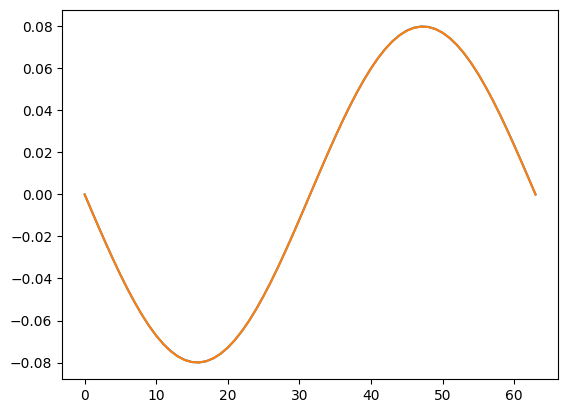

In [15]:
import matplotlib.pyplot as plt
plt.plot(y_init.to('cpu').detach().numpy())
plt.plot(y_init_pred.to('cpu').detach().numpy())

## Parameter Derivatives

- Goal:
  compute per-sample derivatives of the network output with respect to trainable parameters
- Tool:
  `torch.func` with `functional_call`, `grad`, and `vmap`
- Output:
  building blocks for the Jacobian matrix $J$


In [16]:
from torch.func import functional_call, vmap, grad

def ft_compute_sample_grads(model, X_init):
    params = {k: v.detach() for k, v in model.named_parameters()}
    buffers = {k: v.detach() for k, v in model.named_buffers()}

    def predict(params, buffers, X_init):
        # prepend batch dimension for processing
        X_init = X_init.unsqueeze(0)
        X_init = X_init.to(device)

        prediction = functional_call(model, (params, buffers), (X_init))

        return prediction.squeeze()

    ft_compute_grad = grad(predict)
    ft_compute_sample_grad = vmap(ft_compute_grad, in_dims=(None, None, 0))
    ft_per_sample_grads = ft_compute_sample_grad(params, buffers, X_init)

    return ft_per_sample_grads


ft_per_sample_grads = ft_compute_sample_grads(model, X_init) # (n_layers, n_samples, out_dim, *)

In [17]:
print(len(ft_per_sample_grads))
print(ft_per_sample_grads.values)

9
<built-in method values of dict object at 0x761e5e16a480>


In [18]:
print('num_layers: ', len(ft_per_sample_grads))
print('num_grads per sample: ', sum(g.shape[-2] * g.shape[-1] if len(g.shape) == 3 else g.shape[-1] for _, g in ft_per_sample_grads.items()))
# (n_layers, n_samples, out_dim, in_dim)
print(list(ft_per_sample_grads.values())[1].shape)

num_layers:  9
num_grads per sample:  162
torch.Size([64, 3, 12])


## Jacobian Assembly

- Object:
  parameter Jacobian $J$
- Role:
  maps parameter perturbations to output perturbations at sampled spatial points
- Use:
  linearized update inside the strong-form time-marching step


In [19]:
W_origin = list(ft_per_sample_grads.values())
print(len(W_origin))
print(W_origin[0][0].shape)

9
torch.Size([3, 4])


In [20]:
def get_W_flatten(W_origin):
  W_flatten = []
  for i in range(len(W_origin)):
    W_flatten.append(torch.flatten(W_origin[i], start_dim=1))
  W_flatten_matrix = W_flatten[0]
  for i in range(1, len(W_origin)):
    W_flatten_matrix = torch.cat((W_flatten_matrix, W_flatten[i]), 1)
  return W_flatten_matrix

In [21]:
def compute_J():
  ft_per_sample_grads = ft_compute_sample_grads(model, X_init)
  W_origin = list(ft_per_sample_grads.values())
  #W_origin = compute_sample_grads(Allen_model, Coe_input, X_init)
  J = get_W_flatten(W_origin)
  return J

In [22]:
J = compute_J()
print(J.shape)

torch.Size([64, 162])


In [23]:
def change_to_np(list_vars):
  numpy_vars = []
  for i in range(len(list_vars)):
    numpy_vars.append(list_vars[i].cpu().detach().numpy())

  return numpy_vars

In [24]:
def store_parameter_size(list_vars):
  iter = len(list_vars)
  mat_size = []
  vec_size = []
  for i in range(iter):
    temp_vec = np.ndarray.flatten(list_vars[i], order='C')
    mat_size.append(list_vars[i].shape)
    vec_size.append(temp_vec.shape)
  return mat_size, vec_size

In [25]:
trainable_params = [param for param in model.parameters() if param.requires_grad]
np_vars = change_to_np(list(trainable_params))
mat_size, vec_size = store_parameter_size(np_vars)
print(mat_size)
print(vec_size)

[(3, 4), (3, 12), (3, 3), (3, 12), (3, 3), (3, 12), (3, 3), (1, 12), (1, 3)]
[(12,), (36,), (9,), (36,), (9,), (36,), (9,), (12,), (3,)]


In [26]:
def unfold_parameters(list_vars):
  mat_size, vec_size = store_parameter_size(list_vars)

  total_len = 0
  for i in range(len(vec_size)):
    total_len = total_len + vec_size[i][0]

  flat_vec = np.zeros(shape=(total_len,))
  iter = len(list_vars)
  index = 0
  for i in range(iter):
    end_index = index + vec_size[i][0]
    flat_vec[index:end_index] = np.ndarray.flatten(list_vars[i], order='C')
    index = index + vec_size[i][0]

  return flat_vec

In [27]:
def fold_vectors(vector, mat_size = mat_size, vec_size = vec_size):
  iter = len(mat_size)
  output_list = []
  index = 0
  for i in range(iter):
    end_index = index + vec_size[i][0]
    temp_mat = vector[index:end_index]
    output_list.append(np.reshape(temp_mat, newshape=mat_size[i], order='C'))
    index = index + vec_size[i][0]

  return output_list

In [28]:
flat_vec = unfold_parameters(np_vars)
print(len(flat_vec))
reconstruct_mat = fold_vectors(flat_vec, mat_size, vec_size)
print(len(reconstruct_mat))
print(reconstruct_mat[2].shape)

162
9
(3, 3)


## Spatial Derivatives

- Quantities:
  $u$, $u_x$, and $u_{xx}$
- Method:
  automatic differentiation with respect to $x$
- Use:
  residual and energy evaluation


In [29]:
torch.manual_seed(42)
def Compute_x_gradient(model: torch.nn.Module,
                       X,
                       device = device):
  loss_res = 0
  model.eval()
  X = X.to(device)

  # 1. Forward pass
  y_pred = model(X)

  # 2. Calculate loss and metric

  y_x = torch.autograd.grad(
      y_pred, X,
      grad_outputs = torch.ones_like(y_pred),
      retain_graph = True,
      create_graph = True)[0]

  y_xx = torch.autograd.grad(
      y_x, X,
      grad_outputs = torch.ones_like(y_x),
      retain_graph = True,
      create_graph = True)[0]

  return y_pred, y_x, y_xx

In [30]:
u, u_x, u_xx = Compute_x_gradient(model, X_init)
u, u_x, u_xx = u.to("cpu").detach().numpy(), u_x.to("cpu").detach().numpy(), u_xx.to("cpu").detach().numpy()
print(u.shape)
print(u_x.shape)
print(u_xx.shape)

(64, 1)
(64, 1)
(64, 1)


## Residual, Energy, and Time Marching

- Interface parameter:
  `epsilon = 0.002`
- Strong-form residual:
  $$
  N(u)=u_{xx}-\frac{1}{\varepsilon^2}u(u^2-1)
  $$
- Energy density:
  $$
  E(u,u_x)=\frac12 u_x^2 + \frac{(u^2-1)^2}{4\varepsilon^2}
  $$
- Time step:
  `delta_t = 1e-7`
- Number of steps:
  `500`
- Stored outputs:
  updated parameters, energy history, condition numbers, and checkpoints


## Compute $N$ and $E$

- Inputs:
  $u$, $u_x$, $u_{xx}$
- Outputs:
  residual $N(u)$ and energy density $E(u,u_x)$


In [31]:
def compute_N(u, u_x, u_xx):
  epsilon = 0.002
  N = u_xx - u * (u**2 - 1)/(epsilon**2)
  return N

In [32]:
def compute_E(u, u_x):
  epsilon = 0.002
  E = 0.5*(u_x**2) + (u**2 - 1)**2/(4*(epsilon**2))
  return E

In [33]:
def compute_r(energy, M, delta_t, previous_r):
  r = previous_r / (1 + delta_t*M/(2*energy))
  return r

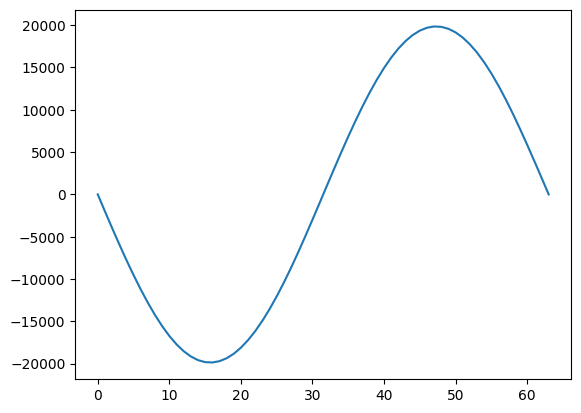

In [34]:
N_t = compute_N(u, u_x, u_xx)

plt.plot(N_t)

## Assign Parameters Back to the Model

- Goal:
  convert flattened parameter updates back into model tensors
- Use:
  restore checkpointed coefficients before evaluation or saving


In [35]:
def update_weights(new_vars):
  weights_tensor = []
  for i in range(len(new_vars)):
    weights_tensor.append(torch.tensor(new_vars[i]).float())

  trainable_params = [(name, param) for name, param in model.named_parameters() if param.requires_grad]
  for i, (name, param_tensor) in enumerate(trainable_params):
    model.state_dict()[name][:] = weights_tensor[i]

  '''
  for i, param_tensor in enumerate(model.state_dict()):
    model.state_dict()[param_tensor][:] = weights_tensor[i]
  '''

  return None

## Main Step

- Inputs:
  current time, step size, and previous auxiliary scalar
- Main tasks:
  assemble $J$, evaluate residual terms, solve the linearized system, and update parameters
- Outputs:
  next-step parameters, energy-related quantities, diagnostics, and timing information


In [36]:
import scipy
import numpy as np
import time as _time
import torch

def _sync_if_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def _get_peak_mem_gb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024**3)
    return np.nan

def one_step_ahead(t_start, delta_t, previous_r, step_idx, cond_every=10):
  breakdown = {"assemble": 0.0, "solve": 0.0, "total": 0.0}

  _sync_if_cuda()
  if torch.cuda.is_available():
      torch.cuda.reset_peak_memory_stats()

  # -------------------------
  # Assemble (AD + J + rhs)
  # -------------------------
  _sync_if_cuda(); t0 = _time.perf_counter()

  # Compute w
  trainable_params = [param for param in model.parameters() if param.requires_grad]
  np_model_vars = change_to_np(list(trainable_params))
  mat_size, vec_size = store_parameter_size(np_model_vars)
  w = unfold_parameters(np_model_vars)

  # Compute J
  J = compute_J()
  J = J.to("cpu").detach().numpy().astype("float64")

  # Compute N (including AD work)
  temp_u, temp_u_x, temp_u_xx = Compute_x_gradient(model, X_init)
  temp_u, temp_u_x, temp_u_xx = (
      temp_u.to("cpu").detach().numpy(),
      temp_u_x.to("cpu").detach().numpy(),
      temp_u_xx.to("cpu").detach().numpy()
  )
  N = compute_N(temp_u, temp_u_x, temp_u_xx)
  N = np.nan_to_num(N, nan=0.0, posinf=1e6, neginf=-1e6)

  # Compute E and r
  E = compute_E(temp_u, temp_u_x)
  E = np.nan_to_num(E, nan=0.0, posinf=1e6, neginf=-1e6)
  energy = np.sum(E)/len(E)
  M = np.reshape(N, newshape=(N.shape[0],))
  M = np.sum(M*M)/len(M)
  new_r = compute_r(energy, M, delta_t, previous_r)
  new_eta = new_r/np.sqrt(energy)

  cond_J = np.nan
  if (step_idx % cond_every) == 0:
      Jc = np.nan_to_num(J, nan=0.0, posinf=0.0, neginf=0.0)
      try:
          S = np.linalg.svd(Jc, compute_uv=False)

          sigma_max = S[0]
          sigma_min = S[-1]

          eps = np.finfo(Jc.dtype).eps

          # Stabilize the smallest singular value with a machine-resolvable lower bound
          sigma_min_safe = max(sigma_min, eps * sigma_max)

          cond_J = float(sigma_max / sigma_min_safe)

      except np.linalg.LinAlgError:
          # SVD failure indicates machine-limit ill-conditioning
          eps = np.finfo(Jc.dtype).eps
          cond_J = float(1.0 / eps)



  # rhs
  right_side = new_eta * N

  _sync_if_cuda(); t1 = _time.perf_counter()
  breakdown["assemble"] = (t1 - t0)

  # -------------------------
  # Solve
  # -------------------------
  _sync_if_cuda(); t0 = _time.perf_counter()
  # dw_dt = scipy.sparse.linalg.lsmr(J, right_side)[0]
  lsmr_maxiter = 2000
#   lsmr_result = scipy.sparse.linalg.lsmr(J, right_side, damp=5e-1)
  lsmr_result = scipy.sparse.linalg.lsmr(J, right_side, maxiter=lsmr_maxiter)
  dw_dt = lsmr_result[0]
  lsmr_itn = lsmr_result[2]

  _sync_if_cuda(); t1 = _time.perf_counter()
  breakdown["solve"] = (t1 - t0)

  # Total (linear system)
  breakdown["total"] = breakdown["assemble"] + breakdown["solve"]

  # -------------------------
  # Update model parameters (excluded from total timing)
  # -------------------------
  new_w = w + delta_t*dw_dt
  new_vars = fold_vectors(new_w)
  update_weights(new_vars)

  peak_mem_gb = _get_peak_mem_gb()

  return new_w, new_r, new_eta, energy, cond_J, breakdown, peak_mem_gb, lsmr_itn


In [37]:
E_0 = compute_E(u, u_x)
print(E_0.squeeze())
energy_0 = np.sum(E_0)/len(E_0)
r_0 = np.sqrt(energy_0)
print(r_0)

[62500.03  62492.03  62468.527 62430.58  62379.69  62317.797 62247.223
 62170.684 62091.203 62011.98  61936.242 61867.11  61807.414 61759.56
 61725.438 61706.344 61702.957 61715.293 61742.793 61784.32  61838.21
 61902.38  61974.336 62051.316 62130.344 62208.344 62282.23  62349.062
 62406.133 62451.12  62482.17  62498.027 62498.043 62482.22  62451.195
 62406.227 62349.137 62282.22  62208.145 62129.914 62050.664 61973.574
 61901.676 61837.785 61784.363 61743.395 61716.418 61704.426 61707.875
 61726.695 61760.26  61807.383 61866.355 61934.926 62010.41  62089.754
 62169.67  62246.836 62318.027 62380.36  62431.35  62469.1   62492.246
 62500.03 ]
249.21318371526817


In [38]:
import time as _time
import numpy as np

# ─────────────────────────────────────────────────────────────
# Simulation loop (measure full wall-clock time)
# ─────────────────────────────────────────────────────────────

loop_start = _time.perf_counter()

t_start = 0
# t_start = final_t
delta_t = 1e-7 # 1e-7
steps = 500

time = []
energy = []
r_list = [r_0]
coefficient_list = []

# Containers for statistics
breakdown_list   = []
peakmem_list     = []
condition_number = []
lsmr_iterations = []

for i in range(steps):
    if i % 10 == 0:
        print(i)

    new_w, new_r, new_eta, new_energy, cond_J, breakdown, peak_mem_gb, lsmr_itn = one_step_ahead(
        t_start, delta_t, r_list[i], step_idx=i, cond_every=10
    )

    t_start += delta_t

    coefficient_list.append(new_w)
    time.append(t_start)
    r_list.append(new_r)
    energy.append(new_energy)

    breakdown_list.append(breakdown)
    peakmem_list.append(peak_mem_gb)
    condition_number.append(cond_J)
    lsmr_iterations.append(lsmr_itn)

    if new_eta < 0.98 or new_eta > 1.02:
        r_list[-1] = np.sqrt(energy[-1])
        print("reset energy")

loop_end = _time.perf_counter()
loop_elapsed = loop_end - loop_start

final_t = t_start
print(f"Final t_start: {final_t:.6e}")
print(f"Total loop time: {loop_elapsed:.4f} seconds")
print(f"elapsed = {loop_elapsed:.4f} s")

# cond(J) sanity check (remove NaNs)
cond_arr = np.asarray(condition_number, dtype=float)
valid = np.isfinite(cond_arr)
print("Number of valid cond(J):", valid.sum(), "/", len(cond_arr))
print("Sample cond(J):", cond_arr[valid][:10])

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
reset energy
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460
470
480
490
Final t_start: 5.000000e-05
Total loop time: 17.9213 seconds
elapsed = 17.9213 s
Number of valid cond(J): 50 / 500
Sample cond(J): [4.50359963e+15 4.50359963e+15 4.50359963e+15 4.50359963e+15
 4.50359963e+15 4.50359963e+15 4.50359963e+15 4.50359963e+15
 4.50359963e+15 4.50359963e+15]


In [39]:
time_targets = [0.00, 0.00001, 0.00003, 0.00005]
time_array = np.array(time)  # stored time history from the simulation
indices_to_update = [np.argmin(np.abs(time_array - T)) for T in time_targets]
print("Target time indices:", indices_to_update)

Target time indices: [0, 99, 299, 499]


In [40]:
# Target times: 50 multiples of 0.000001 starting from 0.000001
time_targets = [i * 0.000001 for i in range(1,51)]
time_array = np.array(time)
print(time_targets)

[1e-06, 2e-06, 3e-06, 4e-06, 4.9999999999999996e-06, 6e-06, 7e-06, 8e-06, 9e-06, 9.999999999999999e-06, 1.1e-05, 1.2e-05, 1.3e-05, 1.4e-05, 1.4999999999999999e-05, 1.6e-05, 1.7e-05, 1.8e-05, 1.8999999999999998e-05, 1.9999999999999998e-05, 2.1e-05, 2.2e-05, 2.3e-05, 2.4e-05, 2.4999999999999998e-05, 2.6e-05, 2.7e-05, 2.8e-05, 2.9e-05, 2.9999999999999997e-05, 3.1e-05, 3.2e-05, 3.2999999999999996e-05, 3.4e-05, 3.5e-05, 3.6e-05, 3.7e-05, 3.7999999999999995e-05, 3.9e-05, 3.9999999999999996e-05, 4.1e-05, 4.2e-05, 4.2999999999999995e-05, 4.4e-05, 4.4999999999999996e-05, 4.6e-05, 4.7e-05, 4.8e-05, 4.9e-05, 4.9999999999999996e-05]


In [41]:
indices_to_update = [np.argmin(np.abs(time_array - T)) for T in time_targets]
print(indices_to_update)

[9, 19, 29, 39, 49, 59, 69, 79, 89, 99, 109, 119, 129, 139, 149, 159, 169, 179, 189, 199, 209, 219, 229, 239, 249, 259, 269, 279, 289, 299, 309, 319, 329, 339, 349, 359, 369, 379, 389, 399, 409, 419, 429, 439, 449, 459, 469, 479, 489, 499]


In [42]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# ============================
# (2) Create the model save directory
# ============================
save_dir = "trained_model"
os.makedirs(save_dir, exist_ok=True)
print("Save directory:", save_dir)

# ============================
# (3) Update parameters and save the model
# ============================
# coefficient_list stores new_w from each time step
for i, idx in enumerate(indices_to_update):
    # Convert coefficient_list[idx] into model-shaped parameters with fold_vectors
    new_vars = fold_vectors(coefficient_list[idx])
    # Update model parameters using new_vars
    update_weights(new_vars)
    
    # Save the updated model checkpoint
    model_save_path = os.path.join(save_dir, f"RadialKAN_at_{time_targets[i]:.5f}.pt")
    torch.save(model.state_dict(), model_save_path)
    print(f"Save completion: {model_save_path}")


Save directory: trained_model
Save completion: trained_model/RadialKAN_at_0.00000.pt
Save completion: trained_model/RadialKAN_at_0.00000.pt
Save completion: trained_model/RadialKAN_at_0.00000.pt
Save completion: trained_model/RadialKAN_at_0.00000.pt
Save completion: trained_model/RadialKAN_at_0.00000.pt
Save completion: trained_model/RadialKAN_at_0.00001.pt
Save completion: trained_model/RadialKAN_at_0.00001.pt
Save completion: trained_model/RadialKAN_at_0.00001.pt
Save completion: trained_model/RadialKAN_at_0.00001.pt
Save completion: trained_model/RadialKAN_at_0.00001.pt
Save completion: trained_model/RadialKAN_at_0.00001.pt
Save completion: trained_model/RadialKAN_at_0.00001.pt
Save completion: trained_model/RadialKAN_at_0.00001.pt
Save completion: trained_model/RadialKAN_at_0.00001.pt
Save completion: trained_model/RadialKAN_at_0.00001.pt
Save completion: trained_model/RadialKAN_at_0.00002.pt
Save completion: trained_model/RadialKAN_at_0.00002.pt
Save completion: trained_model/Radi

In [43]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# ============================
# (1) Choose target times and matching indices
# ============================
time_targets = [0.00, 0.00002, 0.00003, 0.00005]
time_array = np.array(time)  # stored time history from the simulation
indices_to_update = [np.argmin(np.abs(time_array - T)) for T in time_targets]
print("Target time indices:", indices_to_update)

# ============================
# (2) Create the model save directory
# ============================
save_dir = "trained_model"
os.makedirs(save_dir, exist_ok=True)
print("Save directory:", save_dir)

# ============================
# (3) Update parameters and save the model
# ============================
# coefficient_list stores new_w from each time step
for i, idx in enumerate(indices_to_update):
    # Convert coefficient_list[idx] into model-shaped parameters with fold_vectors
    new_vars = fold_vectors(coefficient_list[idx])
    # Update model parameters using new_vars
    update_weights(new_vars)
    
    # Save the updated model checkpoint
    model_save_path = os.path.join(save_dir, f"RadialKAN_at_{time_targets[i]:.5f}.pt")
    torch.save(model.state_dict(), model_save_path)
    print(f"Save completion: {model_save_path}")


Target time indices: [0, 199, 299, 499]
Save directory: trained_model
Save completion: trained_model/RadialKAN_at_0.00000.pt
Save completion: trained_model/RadialKAN_at_0.00002.pt
Save completion: trained_model/RadialKAN_at_0.00003.pt
Save completion: trained_model/RadialKAN_at_0.00005.pt


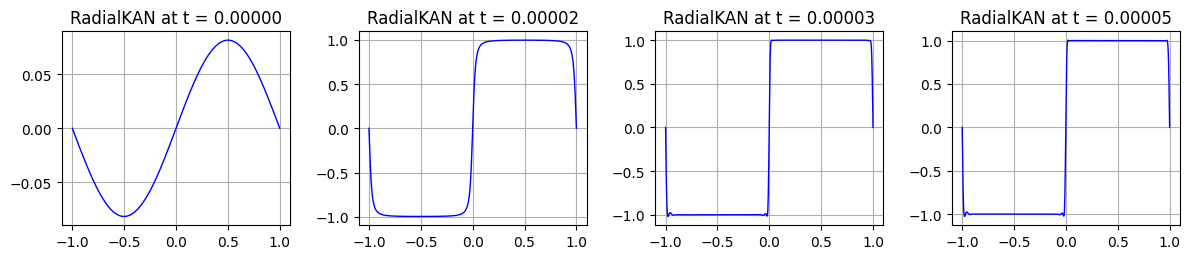

In [44]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# Set device and X_init (with requires_grad enabled)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_init = torch.linspace(-1, 1, 1001).reshape(-1, 1).to(device).requires_grad_()

# Set the saved model directory and target times
save_dir = "trained_model"
time_targets = [0.00, 0.00002, 0.00003, 0.00005]

# Create a 1x4 subplot layout
fig, axes = plt.subplots(1, 4, figsize=(12, 2.7))
axes = axes.flatten()

for i, T in enumerate(time_targets):
    model_load_path = os.path.join(save_dir, f"RadialKAN_at_{T:.5f}.pt")
    
    # Load the model and switch to evaluation mode
    model.load_state_dict(torch.load(model_load_path, map_location=device, weights_only=True))
    model.to(device)
    model.eval()
    
    # Use Compute_x_gradient to evaluate test_u, test_u_x, and test_u_xx (only test_u is plotted here)
    test_u, test_u_x, test_u_xx = Compute_x_gradient(model, X_init)
    test_u = test_u.cpu().detach().numpy()
    
    # x coordinates as a NumPy array
    x_np = X_init.cpu().detach().numpy().flatten()
    
    # Plot test_u on the subplot
    ax = axes[i]
    ax.plot(x_np, test_u.flatten(), 'b-', linewidth=1)
    ax.set_title(f"RadialKAN at t = {T:.5f}")
    ax.grid(True)
    # ax.set_ylim(-1.3, 1.3)

results_dir = "results"
os.makedirs(results_dir, exist_ok=True)  # create the results directory if needed
figure_save_path = os.path.join(results_dir, "RadialKAN-Allen.pdf")

plt.tight_layout()
plt.subplots_adjust(
    wspace=0.3, 
    hspace=0.4   
)
# plt.savefig(figure_save_path, dpi=300, bbox_inches='tight')
plt.show()

In [45]:
test_u, test_u_x, test_u_xx = Compute_x_gradient(model, X_init)

<class 'list'> <class 'list'>


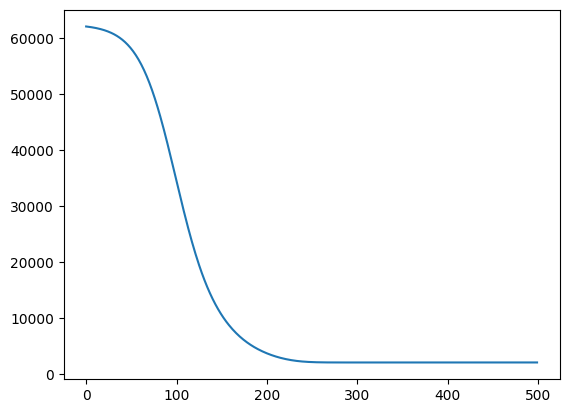

In [46]:
print(type(energy), type(r_list))
# The result should be a list or NumPy array.
plt.plot(energy)

In [47]:
# Count all model parameters
total_params = sum(p.numel() for p in model.parameters())

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameter count:", total_params)
print("Trainable parameter count:", trainable_params)

Total parameter count: 162
Trainable parameter count: 162


In [48]:
for i, layer in enumerate(model.layers):
    print(i, type(layer), layer.use_base_update if hasattr(layer, 'use_base_update') else None)

0 <class '__main__.FastKANFirstLayer'> False
1 <class '__main__.FastKANLayer'> True
2 <class '__main__.FastKANLayer'> True
3 <class '__main__.FastKANLayer'> True
4 <class '__main__.FastKANLayer'> True


In [49]:
for name, param in model.named_parameters():
    print(name, param.shape, param.numel(), param.requires_grad)

layers.0.spline_linear.weight torch.Size([3, 4]) 12 True
layers.1.spline_linear.weight torch.Size([3, 12]) 36 True
layers.1.base_linear.weight torch.Size([3, 3]) 9 True
layers.2.spline_linear.weight torch.Size([3, 12]) 36 True
layers.2.base_linear.weight torch.Size([3, 3]) 9 True
layers.3.spline_linear.weight torch.Size([3, 12]) 36 True
layers.3.base_linear.weight torch.Size([3, 3]) 9 True
layers.4.spline_linear.weight torch.Size([1, 12]) 12 True
layers.4.base_linear.weight torch.Size([1, 3]) 3 True


In [50]:
for i, layer in enumerate(model.layers):
    print(f"Layer {i}: {type(layer)}, use_base_update={getattr(layer, 'use_base_update', None)}")

Layer 0: <class '__main__.FastKANFirstLayer'>, use_base_update=False
Layer 1: <class '__main__.FastKANLayer'>, use_base_update=True
Layer 2: <class '__main__.FastKANLayer'>, use_base_update=True
Layer 3: <class '__main__.FastKANLayer'>, use_base_update=True
Layer 4: <class '__main__.FastKANLayer'>, use_base_update=True


In [51]:
total, trainable = 0, 0
for name, param in model.named_parameters():
    print(name, param.shape, param.numel(), param.requires_grad)
    total += param.numel()
    if param.requires_grad:
        trainable += param.numel()
print("Total:", total, "Trainable:", trainable)


layers.0.spline_linear.weight torch.Size([3, 4]) 12 True
layers.1.spline_linear.weight torch.Size([3, 12]) 36 True
layers.1.base_linear.weight torch.Size([3, 3]) 9 True
layers.2.spline_linear.weight torch.Size([3, 12]) 36 True
layers.2.base_linear.weight torch.Size([3, 3]) 9 True
layers.3.spline_linear.weight torch.Size([3, 12]) 36 True
layers.3.base_linear.weight torch.Size([3, 3]) 9 True
layers.4.spline_linear.weight torch.Size([1, 12]) 12 True
layers.4.base_linear.weight torch.Size([1, 3]) 3 True
Total: 162 Trainable: 162


In [52]:
import os
import numpy as np
import scipy.io as sio

save_dir = 'results/EvoKAN_strong_solution'
os.makedirs(save_dir, exist_ok=True)

time_targets = [i * 0.000001 for i in range(1, 51)]
time_array = np.array(time)
indices_to_update = [np.argmin(np.abs(time_array - T)) for T in time_targets]

for T, idx in zip(time_targets, indices_to_update):
    new_vars = fold_vectors(coefficient_list[idx])
    update_weights(new_vars)

    test_u, test_u_x, test_u_xx = Compute_x_gradient(model, X_init)

    test_u = test_u.cpu().detach().numpy().flatten()
    x_np = X_init.cpu().detach().numpy().flatten()

    file_name = f"EvoKAN_SF_solution_at_{T:.6f}.mat"
    file_path = os.path.join(save_dir, file_name)

    sio.savemat(file_path, {
        'x': x_np.reshape(-1, 1),
        'u': test_u.reshape(-1, 1)
    })

    print(f"Saved solution for t = {T:.6f} at {file_path}")


Saved solution for t = 0.000001 at results/EvoKAN_strong_solution/EvoKAN_SF_solution_at_0.000001.mat
Saved solution for t = 0.000002 at results/EvoKAN_strong_solution/EvoKAN_SF_solution_at_0.000002.mat
Saved solution for t = 0.000003 at results/EvoKAN_strong_solution/EvoKAN_SF_solution_at_0.000003.mat
Saved solution for t = 0.000004 at results/EvoKAN_strong_solution/EvoKAN_SF_solution_at_0.000004.mat
Saved solution for t = 0.000005 at results/EvoKAN_strong_solution/EvoKAN_SF_solution_at_0.000005.mat
Saved solution for t = 0.000006 at results/EvoKAN_strong_solution/EvoKAN_SF_solution_at_0.000006.mat
Saved solution for t = 0.000007 at results/EvoKAN_strong_solution/EvoKAN_SF_solution_at_0.000007.mat
Saved solution for t = 0.000008 at results/EvoKAN_strong_solution/EvoKAN_SF_solution_at_0.000008.mat
Saved solution for t = 0.000009 at results/EvoKAN_strong_solution/EvoKAN_SF_solution_at_0.000009.mat
Saved solution for t = 0.000010 at results/EvoKAN_strong_solution/EvoKAN_SF_solution_at_0.0

In [53]:
import numpy as np

def stats(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]  # remove NaNs
    if arr.size == 0:
        return {"min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan}
    return {
        "min":  float(np.min(arr)),
        "max":  float(np.max(arr)),
        "mean": float(np.mean(arr)),
        "std":  float(np.std(arr)),
    }

assemble_times = [b["assemble"] for b in breakdown_list]
solve_times    = [b["solve"]    for b in breakdown_list]
total_times    = [b["total"]    for b in breakdown_list]
peak_mem       = peakmem_list
condJ          = condition_number
lsmr_iters     = lsmr_iterations

assemble_stats = stats(assemble_times)
solve_stats    = stats(solve_times)
total_stats    = stats(total_times)
mem_stats      = stats(peak_mem)
cond_stats     = stats(condJ)
lsmr_iter_stats = stats(lsmr_iters)

print(f"""
=== Per-step statistics over all time steps ===

[Assemble]
  min  = {assemble_stats['min']:.4e} s
  max  = {assemble_stats['max']:.4e} s
  mean = {assemble_stats['mean']:.4e} s
  std  = {assemble_stats['std']:.4e} s

[Solve]
  min  = {solve_stats['min']:.4e} s
  max  = {solve_stats['max']:.4e} s
  mean = {solve_stats['mean']:.4e} s
  std  = {solve_stats['std']:.4e} s

[Total (linear system)]
  min  = {total_stats['min']:.4e} s
  max  = {total_stats['max']:.4e} s
  mean = {total_stats['mean']:.4e} s
  std  = {total_stats['std']:.4e} s

[Peak memory]
  min  = {mem_stats['min']:.4f} GB
  max  = {mem_stats['max']:.4f} GB
  mean = {mem_stats['mean']:.4f} GB
  std  = {mem_stats['std']:.4f} GB

[Condition number] (computed every 10 steps; NaN ignored)
  min  = {cond_stats['min']:.4e}
  max  = {cond_stats['max']:.4e}
  mean = {cond_stats['mean']:.4e}
  std  = {cond_stats['std']:.4e}

[LSMR iterations]
  min  = {lsmr_iter_stats['min']:.4e}
  max  = {lsmr_iter_stats['max']:.4e}
  mean = {lsmr_iter_stats['mean']:.4e}
  std  = {lsmr_iter_stats['std']:.4e}
""")


=== Per-step statistics over all time steps ===

[Assemble]
  min  = 1.3374e-02 s
  max  = 3.4609e-02 s
  mean = 1.3757e-02 s
  std  = 1.3098e-03 s

[Solve]
  min  = 5.2791e-03 s
  max  = 2.8915e-01 s
  mean = 2.0988e-02 s
  std  = 2.0225e-02 s

[Total (linear system)]
  min  = 1.8866e-02 s
  max  = 3.0269e-01 s
  mean = 3.4744e-02 s
  std  = 2.0362e-02 s

[Peak memory]
  min  = 0.0166 GB
  max  = 0.0166 GB
  mean = 0.0166 GB
  std  = 0.0000 GB

[Condition number] (computed every 10 steps; NaN ignored)
  min  = 4.5036e+15
  max  = 4.5036e+15
  mean = 4.5036e+15
  std  = 0.0000e+00

[LSMR iterations]
  min  = 7.6000e+01
  max  = 8.1500e+02
  mean = 2.9785e+02
  std  = 2.2201e+02



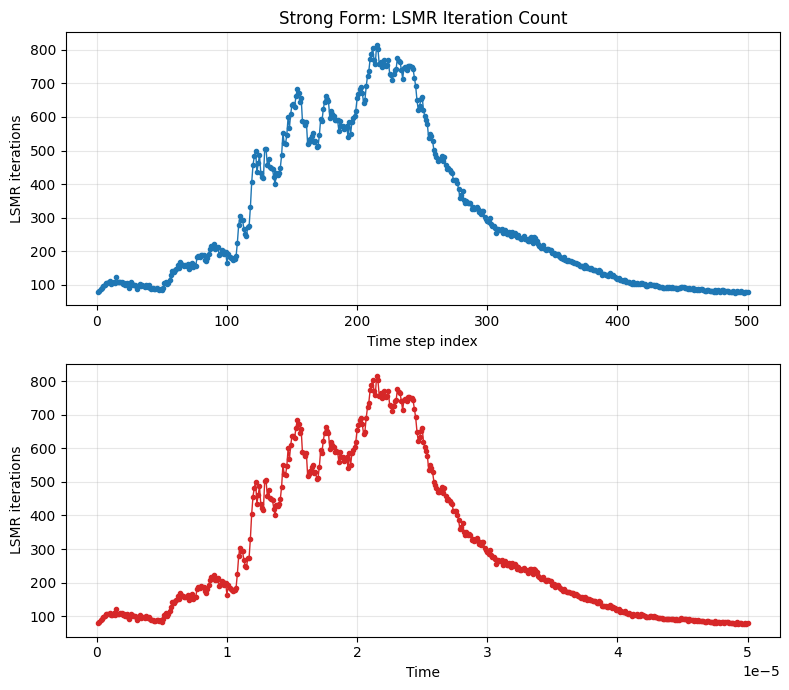

cwd: /home/user/bongseok
Saved figure to: results/lsmr_diagnostics/strong_lsmr_iteration_count.png
Figure exists: True
Saved LSMR iteration history to: results/lsmr_diagnostics/EvoKAN_strong_lsmr_iterations.mat
MAT exists: True


In [54]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

lsmr_iters = np.asarray(lsmr_iterations, dtype=float)
time_arr = np.asarray(time, dtype=float)
step_arr = np.arange(1, len(lsmr_iters) + 1)

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharey=True)

axes[0].plot(step_arr, lsmr_iters, marker='o', markersize=3, linewidth=1)
axes[0].set_xlabel('Time step index')
axes[0].set_ylabel('LSMR iterations')
axes[0].set_title('Strong Form: LSMR Iteration Count')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_arr, lsmr_iters, marker='o', markersize=3, linewidth=1, color='tab:red')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('LSMR iterations')
axes[1].grid(True, alpha=0.3)

save_dir = "results/lsmr_diagnostics"
os.makedirs(save_dir, exist_ok=True)
fig_path = os.path.join(save_dir, 'strong_lsmr_iteration_count.png')
mat_path = os.path.join(save_dir, 'EvoKAN_strong_lsmr_iterations.mat')

plt.tight_layout()
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

sio.savemat(
    mat_path,
    {
        'step': step_arr.reshape(-1, 1),
        'time': time_arr.reshape(-1, 1),
        'lsmr_iterations': lsmr_iters.reshape(-1, 1),
    }
)

print(f'cwd: {os.getcwd()}')
print(f'Saved figure to: {fig_path}')
print(f'Figure exists: {os.path.exists(fig_path)}')
print(f'Saved LSMR iteration history to: {mat_path}')
print(f'MAT exists: {os.path.exists(mat_path)}')
